[Flax Task](https://cernbox.cern.ch/external/public/d0aQYu1AkObrch2/2025-GSoC-TMVA_Exercise_Inference_JAX.docx?app=MS%20365%20on%20Cloud&fileId=eoshome-s%21251333146&contextRouteName=files-public-link&contextRouteParams.driveAliasAndItem=public/d0aQYu1AkObrch2) [Exercise 4]
<br>
Aim: Implement a function in Python that shall take an in-memory model object from FLAX and return the model configuration in the form of a dictionary.

1.
Create a flax model using flax.nnx library
<br>
[Model definition](https://github.com/google/flax/blob/main/examples/nnx_toy_examples/01_functional_api.py)

step: 0, loss: 2.530604600906372
step: 1000, loss: 0.007554062642157078
step: 2000, loss: 0.0075259143486619
step: 3000, loss: 0.00753231393173337
step: 4000, loss: 0.007574009243398905
step: 5000, loss: 0.007530384697020054
step: 6000, loss: 0.007543306332081556
step: 7000, loss: 0.0075466083362698555
step: 8000, loss: 0.007572424132376909
step: 9000, loss: 0.00754602300003171
times called: 10000


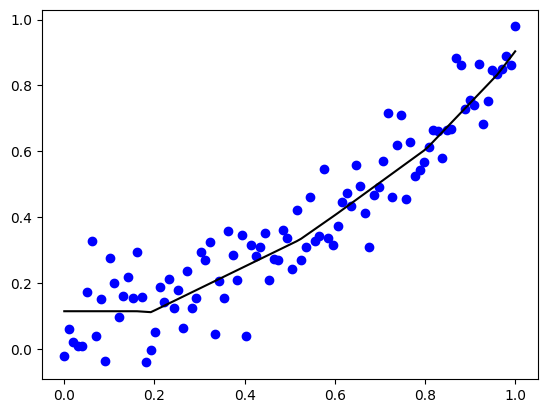

In [1]:
# Copyright 2024 The Flax Authors.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# %%
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from flax import nnx

X = np.linspace(0, 1, 100)[:, None]
Y = 0.8 * X**2 + 0.1 + np.random.normal(0, 0.1, size=X.shape)


def dataset(batch_size):
  while True:
    idx = np.random.choice(len(X), size=batch_size)
    yield X[idx], Y[idx]


class Linear(nnx.Module):
  def __init__(self, din: int, dout: int, *, rngs: nnx.Rngs):
    self.w = nnx.Param(jax.random.uniform(rngs.params(), (din, dout)))
    self.b = nnx.Param(jnp.zeros((dout,)))

  def __call__(self, x):
    return x @ self.w.value + self.b.value


class Count(nnx.Variable[nnx.A]):
  pass


class MLP(nnx.Module):
  def __init__(self, din, dhidden, dout, *, rngs: nnx.Rngs):
    self.count = Count(jnp.array(0))
    self.linear1 = Linear(din, dhidden, rngs=rngs)
    self.linear2 = Linear(dhidden, dout, rngs=rngs)

  def __call__(self, x):
    self.count.value += 1
    x = self.linear1(x)
    x = jax.nn.relu(x)
    x = self.linear2(x)
    return x


graphdef, params, counts = nnx.split(
  MLP(din=1, dhidden=32, dout=1, rngs=nnx.Rngs(0)), nnx.Param, Count
)


@jax.jit
def train_step(params, counts, batch):
  x, y = batch

  def loss_fn(params):
    model = nnx.merge(graphdef, params, counts)
    y_pred = model(x)
    new_counts = nnx.state(model, Count)
    loss = jnp.mean((y - y_pred) ** 2)
    return loss, new_counts

  grad, counts = jax.grad(loss_fn, has_aux=True)(params)
  #                          |-------- sgd ---------|
  params = jax.tree.map(lambda w, g: w - 0.1 * g, params, grad)

  return params, counts


@jax.jit
def test_step(params: nnx.State, counts: nnx.State, batch):
  x, y = batch
  model = nnx.merge(graphdef, params, counts)
  y_pred = model(x)
  loss = jnp.mean((y - y_pred) ** 2)
  return {'loss': loss}


total_steps = 10_000
for step, batch in enumerate(dataset(32)):
  params, counts = train_step(params, counts, batch)

  if step % 1000 == 0:
    logs = test_step(params, counts, (X, Y))
    print(f"step: {step}, loss: {logs['loss']}")

  if step >= total_steps - 1:
    break

model = nnx.merge(graphdef, params, counts)
print('times called:', model.count.value)

y_pred = model(X)

plt.scatter(X, Y, color='blue')
plt.plot(X, y_pred, color='black')
plt.show()

2. Create a Python function to return model configuration


**Handling Nested Layers in FLAX**

The function recursively processes FLAX models with nested layers. It extracts the configuration of both top-level layers and their sub-layers (e.g., an encoder with linear1 and linear2) **recursively**. This ensures that the full model, including nested components, is captured in a dictionary format.

In [2]:
def get_model_config(model: nnx.Module) -> dict:
    '''
    Extracts the configuration of a Flax model recursively, so that any nested layers are not missed.

    Input:
        model: Flax model of type nnx.Module

    Output:
        A dictionary containing the model configuration, including:
        - Model name
        - Layer information (name, type, input/output dimensions, number of parameters, data type)
        - Total number of parameters in the model
    '''

    # Initialize a dictionary to store the overall model configuration
    model_config = {}

    # Store the model's class name (i.e., model type)
    model_config['Model Name'] = model.__class__.__name__

    # Initialize a dictionary to store detailed layer-wise information
    model_config['layer information'] = {}

    # Initialize a list to store the number of parameters used in every layer
    layer_param_counts = []

    # Helper function to recursively gather configuration data from the layers of the model
    def helper(layer_dict, layer_obj):
        '''
        Recursive function to extract configuration for each layer and its parameters

        Input:
            layer_dict: Dictionary to store layer information (will be passed recursively)
            layer_obj: The current layer object to extract information from
        '''

        # Iterate over the children (layers) of the current layer object
        for layer_name, layer_params in layer_obj.iter_children():

            # Initialize a new dictionary entry for each layer in the main dictionary
            layer_dict[layer_name] = {}

            # Store the class name of the current layer
            layer_dict[layer_name]['class'] = layer_params.__class__.__name__

            # If the current layer has nested layers, recursively extract information from those
            if any(layer_params.iter_children()):
                # If nested, initialize a dictionary for the nested layers
                layer_dict[layer_name]['layers'] = {}
                # Recursively call helper for nested layers
                helper(layer_dict[layer_name]['layers'], layer_params)
            else:
                # For layers without further nested layers, iterate over the parameters of the layer
                for param_type, param in vars(layer_params).items():

                    # Consider only parameters of type 'Param' with a 2D shape (weights/kernels)
                    if param.__class__.__name__ == 'Param' and param.value.ndim == 2:
                        # Extract the shape of the parameter (input_dim, output_dim)
                        param_shape = param.value.shape

                        # Store the input/output shape of the layer
                        layer_dict[layer_name]['shape'] = {
                            'input shape': (None, param_shape[0]),
                            'output shape': (None, param_shape[1])
                        }

                        # Calculate the total number of parameters for this layer
                        # Formula: (input_dim * output_dim) + output_dim (for the bias)
                        layer_param_count = param_shape[0] * param_shape[1] + param_shape[1]

                        # Append the number of parameters of this layer to the list
                        layer_param_counts.append(layer_param_count)

                        layer_dict[layer_name]['number of parameters'] = layer_param_count

                        # Store the data type of the parameters in the layer
                        layer_dict[layer_name]['dtype'] = str(param.value.dtype)

    # Start the recursion by passing the model's base layer information dictionary and model object
    helper(model_config['layer information'], model)

    # Calculate the total number of parameters used in the model
    total_number_of_params = sum(layer_param_counts)

    # Store the total number of parameters in the model configuration
    model_config['Total number of parameters'] = total_number_of_params

    # Return the final model configuration
    return model_config


3. Pass the model in the function and print the model configuration

In [3]:
from pprint import pprint

# Print the model configuration
model_config = get_model_config(model)
pprint(model_config)

{'Model Name': 'MLP',
 'Total number of parameters': 97,
 'layer information': {'linear1': {'class': 'Linear',
                                   'dtype': 'float32',
                                   'number of parameters': 64,
                                   'shape': {'input shape': (None, 1),
                                             'output shape': (None, 32)}},
                       'linear2': {'class': 'Linear',
                                   'dtype': 'float32',
                                   'number of parameters': 33,
                                   'shape': {'input shape': (None, 32),
                                             'output shape': (None, 1)}}}}
